# 06 - Feature Selection and Signal Audit

Run saved EDA/signal checks and inspect feature leakage/missingness/importance.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('06_feature_selection', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '06_feature_selection')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\06_feature_selection
Notebook log file: C:\Code\flight-disruption-prediction\logs\06_feature_selection_20260420_173445.log


## 2. Run Signal Audit

In [2]:
RUN_SIGNAL_AUDIT = False
if RUN_SIGNAL_AUDIT:
    cmd = [sys.executable, str(PROJECT_ROOT / 'scripts' / 'eda_signal_audit.py')]
    completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
    print(completed.stdout)
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError('EDA signal audit failed')
else:
    print('Signal audit skipped. Set RUN_SIGNAL_AUDIT=True to rebuild audit outputs.')

Signal audit skipped. Set RUN_SIGNAL_AUDIT=True to rebuild audit outputs.


## 3. Feature Tables and Visuals


feature_group_model_results.csv


,group,numeric_features,categorical_features,train_rows,test_rows,positive_rate_test,balanced_accuracy,f1_macro,precision_disrupted,recall_disrupted,f1_disrupted,roc_auc,average_precision,used_numeric,used_categorical
0,combined_available,27,4,66631,16658,0.179673,0.644245,0.586479,0.297002,0.599064,0.397121,0.690079,0.335743,"['altitude_change_count', 'altitude_variance',...","['destination', 'eda_route', 'origin', 'weathe..."
1,temporal_derived,6,0,66631,16658,0.179673,0.627634,0.557677,0.270836,0.622118,0.377381,0.675279,0.314018,"['eda_dep_hour', 'eda_dep_day_of_week', 'eda_d...",[]
2,congestion_derived,5,0,66631,16658,0.179673,0.586661,0.534251,0.244444,0.536585,0.335878,0.629005,0.280712,"['eda_origin_freq', 'eda_dest_freq', 'eda_rout...",[]
3,airport_route_categorical,5,3,66631,16658,0.179673,0.576576,0.505498,0.228350,0.589375,0.329166,0.607986,0.250606,"['eda_origin_freq', 'eda_dest_freq', 'eda_rout...","['origin', 'destination', 'eda_route']"
4,trajectory_existing,12,0,66631,16658,0.179673,0.543472,0.527605,0.224192,0.359171,0.276066,0.573491,0.233277,"['flight_duration', 'trajectory_length', 'mean...",[]
5,weather_existing,4,1,66631,16658,0.179673,0.519784,0.512496,0.202229,0.291012,0.238630,0.541246,0.192990,"['wind_speed', 'visibility', 'temperature', 'p...",['weather_confidence']



combined_feature_importance.csv


,feature,importance
0,eda_dep_hour,0.128402
1,eda_dep_day_of_week,0.100088
2,origin,0.099255
3,eda_is_weekend,0.080397
4,eda_dest_flights_1hr,0.064963
5,destination,0.063531
6,temperature,0.037866
7,speed_std,0.037830
8,eda_route,0.037472
9,altitude_variance,0.032430



numeric_univariate_auc.csv


,feature,non_null_pct,directional_auc,spearman_abs,higher_means_more_disrupted
0,eda_is_weekend,100.000,0.5565,0.1352,True
1,eda_dep_day_of_week,100.000,0.5563,0.1346,True
2,mean_speed,99.169,0.5372,0.0529,True
3,eda_scheduled_duration_min,100.000,0.5367,0.0521,True
4,max_speed,99.169,0.5320,0.0455,True
5,mean_altitude,99.246,0.5320,0.0455,True
6,eda_dest_flights_1hr,100.000,0.5309,0.0439,False
7,eda_route_freq,100.000,0.5304,0.0432,True
8,altitude_change_count,100.000,0.5299,0.0425,True
9,eda_dep_hour,100.000,0.5275,0.0392,True



missingness.csv


,column,null_pct
0,lateral_deviation_mean_km,100.0
1,lateral_deviation_max_km,100.0
2,lateral_deviation_std_km,100.0
3,route_stretch_ratio,100.0
4,is_weekend,100.0
5,dep_month,100.0
6,dep_day_of_week,100.0
7,dep_hour,100.0
8,approach_deviation_km,100.0
9,altitude_deviation_mean_m,100.0



C:\Code\flight-disruption-prediction\outputs\pipeline_report\ml_dataset_missingness.png


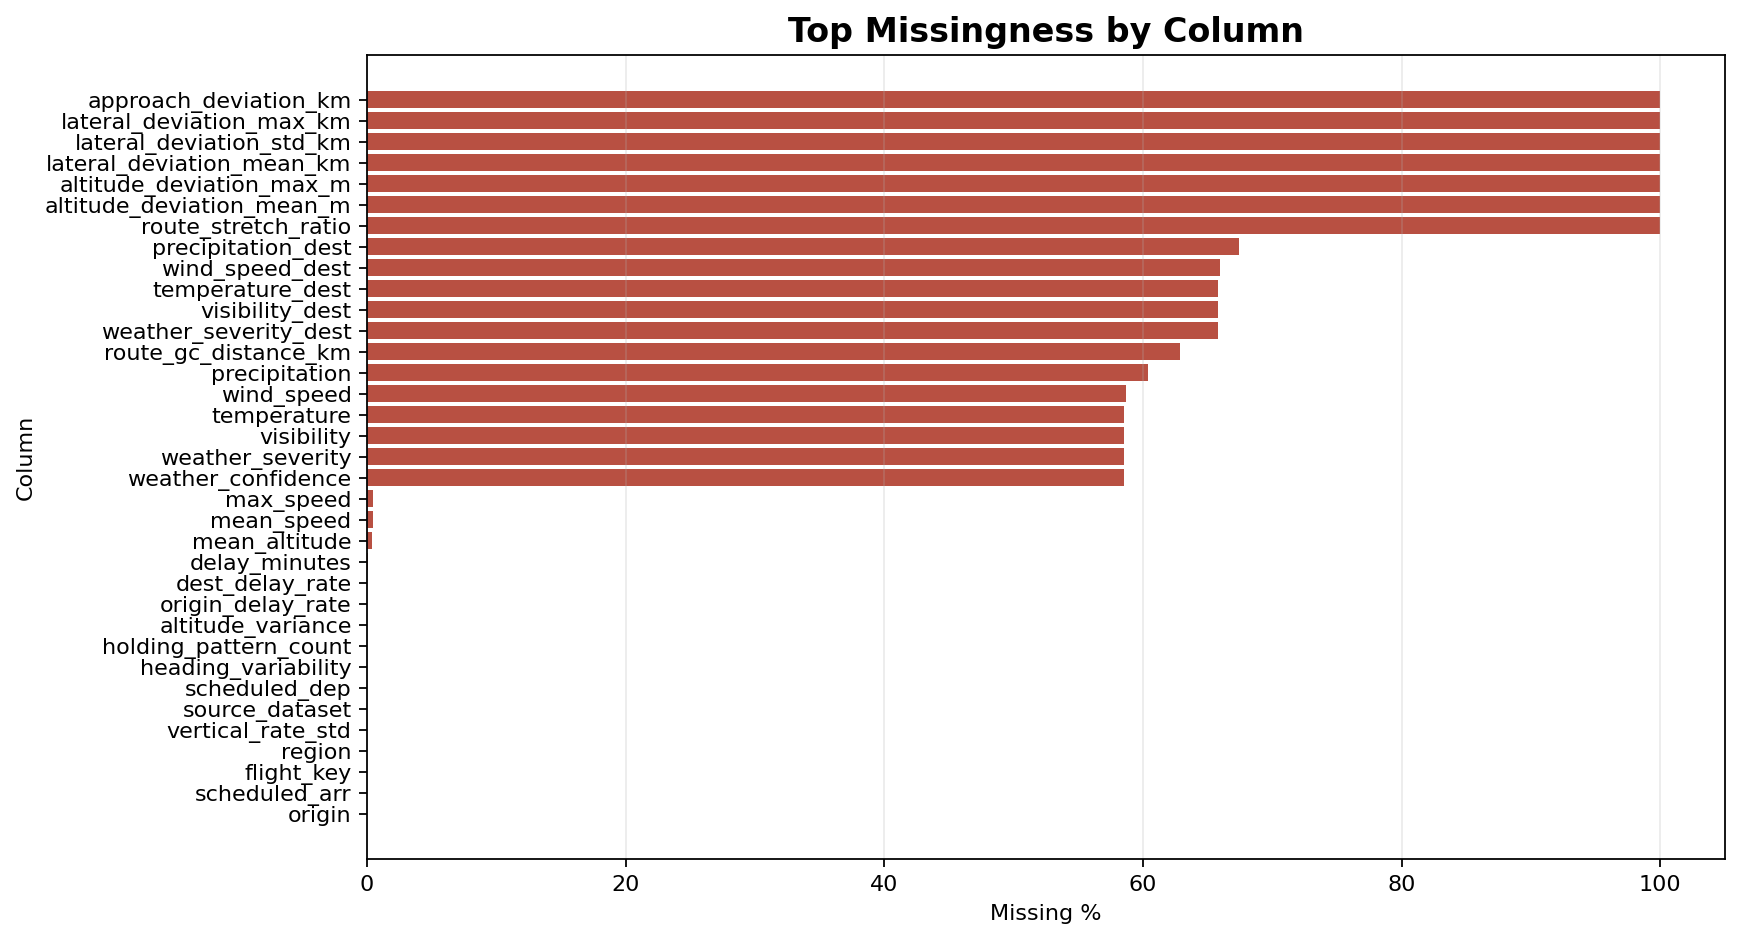


C:\Code\flight-disruption-prediction\outputs\pipeline_report\top_feature_importance.png


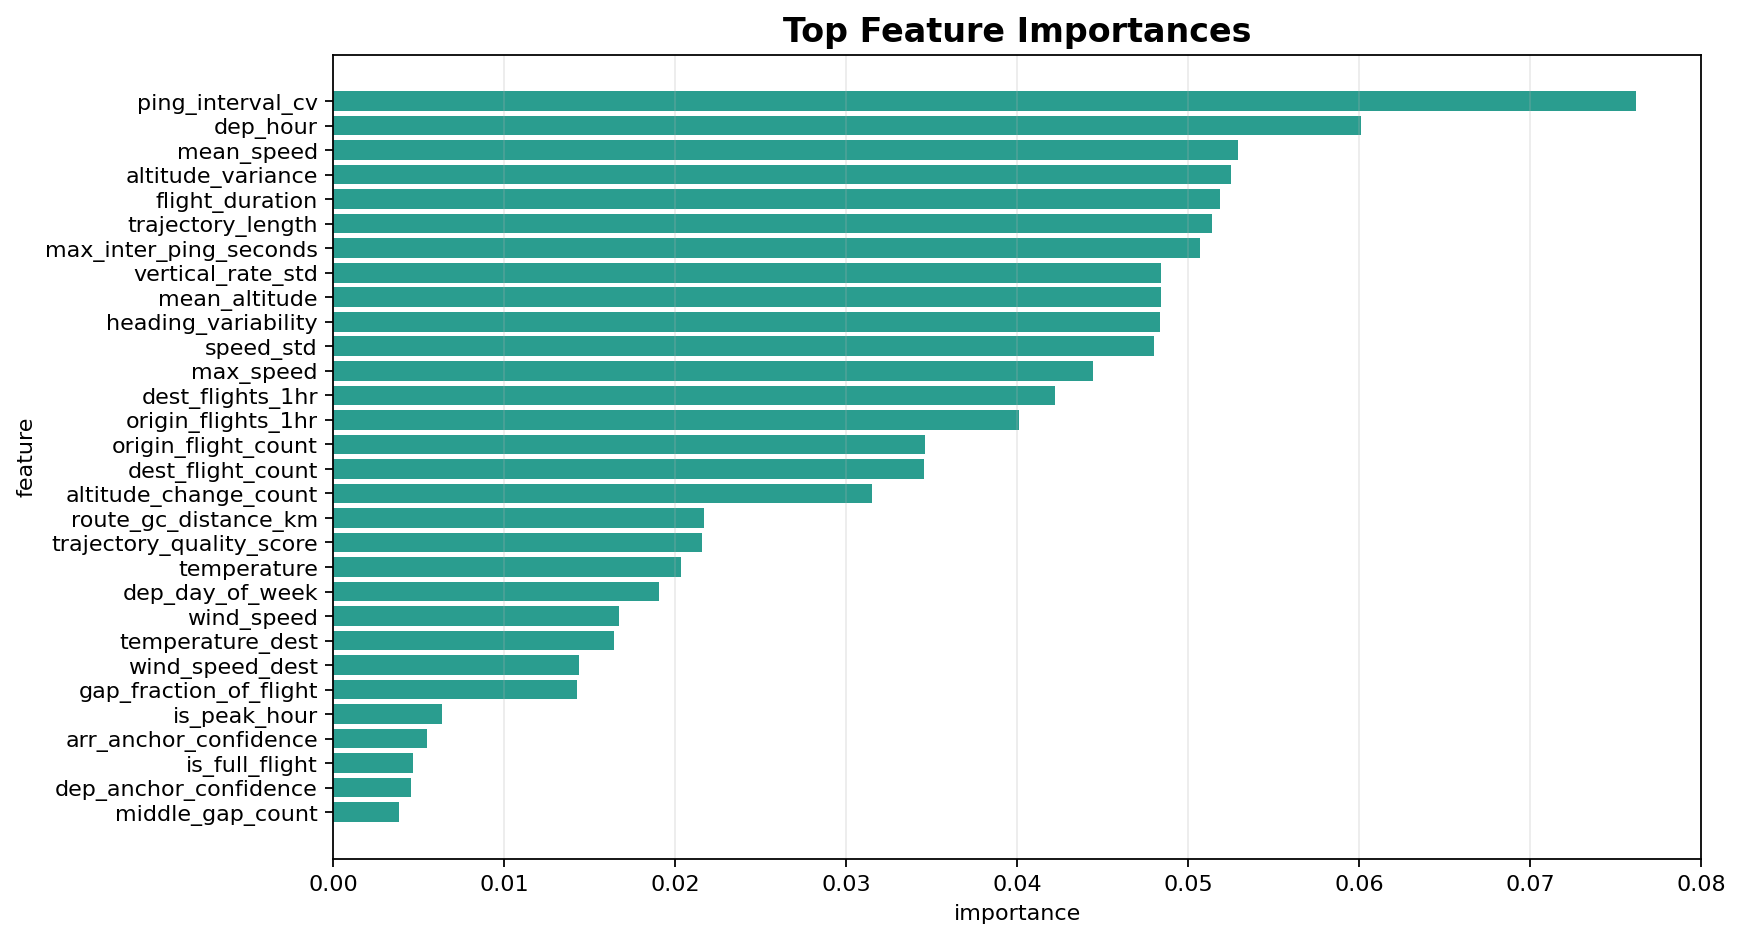


C:\Code\flight-disruption-prediction\outputs\feature_importance_by_category.png


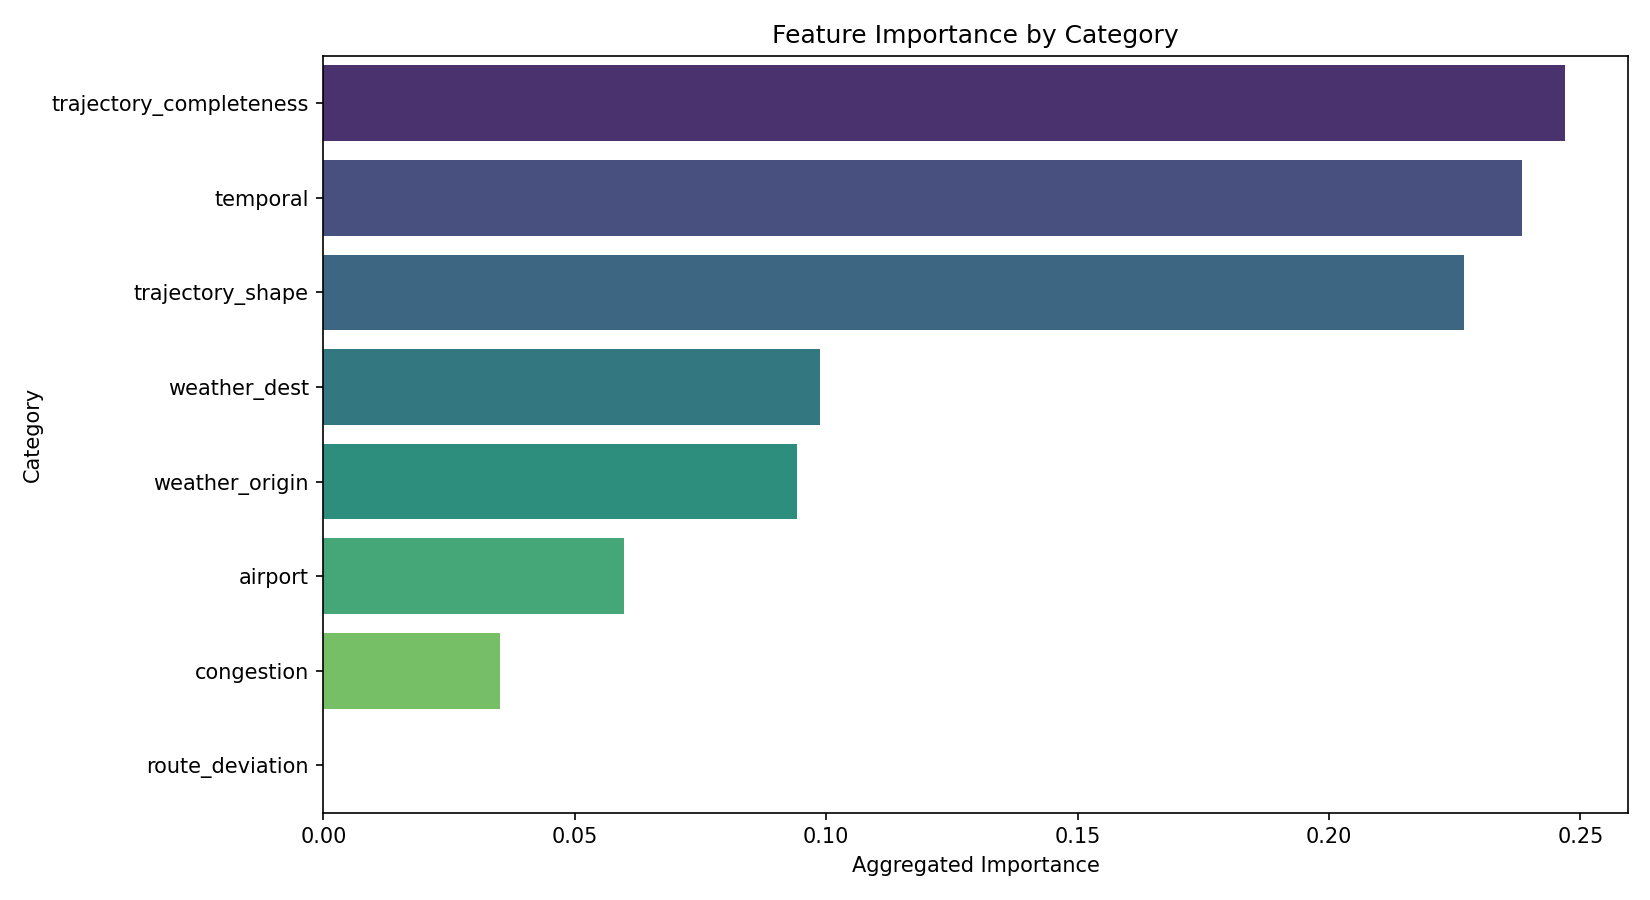

In [3]:
audit_dir = PROJECT_ROOT / 'outputs' / 'eda_signal_audit'
report_dir = PROJECT_ROOT / 'outputs' / 'pipeline_report'
for csv_name in ['feature_group_model_results.csv', 'combined_feature_importance.csv', 'numeric_univariate_auc.csv', 'missingness.csv']:
    path = audit_dir / csv_name
    if path.exists():
        print('\n' + csv_name)
        display(pd.read_csv(path).head(20))

for image_name in ['ml_dataset_missingness.png', 'top_feature_importance.png', 'feature_importance_by_category.png']:
    for folder in [report_dir, PROJECT_ROOT / 'outputs']:
        image_path = folder / image_name
        if image_path.exists():
            print('\n' + str(image_path))
            display(Image(filename=str(image_path)))
            break